# Regression Algorithms

## California Housing Dataset — Linear Models, Regularisation, and Polynomial Features

**Dataset:** `sklearn.datasets.fetch_california_housing` — 20,640 rows, 8 numeric
features. Target is median house value (in $100,000s) for California districts (1990).

**Goal:** Understand how linear regression works, what regularisation does to
coefficients, and how polynomial features affect model complexity.

### Tech Stack

| Library | Purpose |
|---|---|
| pandas / numpy | Data handling |
| matplotlib / seaborn | Visualisation |
| scikit-learn | Models, metrics, preprocessing |

## Setup and Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

plt.style.use("seaborn-v0_8-whitegrid")

print("All imports successful.")

All imports successful.


## Load and Prepare the Dataset

Loading California Housing directly from sklearn. The dataset is clean — no missing
values, no categorical columns — so preparation here focuses on understanding the
features, the target distribution, and setting up the train/test split.

In [4]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame
print(f"Shape: {df.shape}")
print(f"\nFeatures: {housing.feature_names}")
print(f"Target:   {housing.target_names}")
print(f"\n{df.dtypes}")

Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target:   ['MedHouseVal']

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [5]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


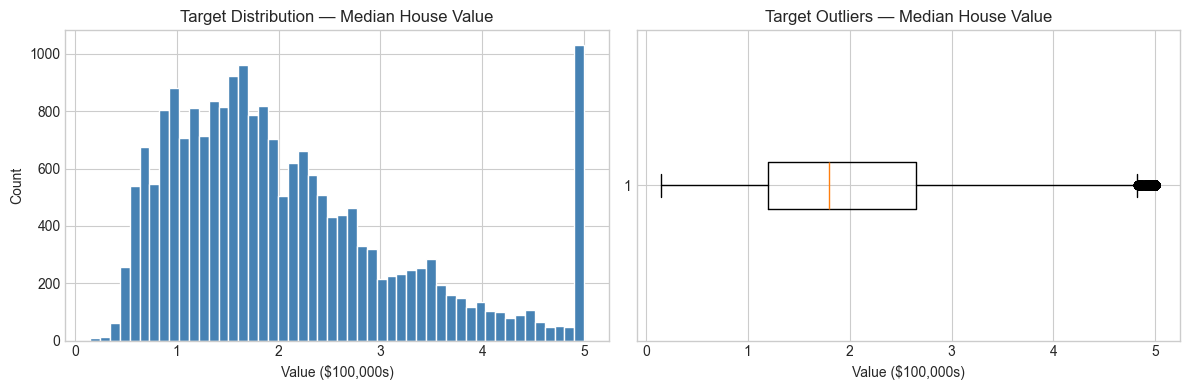

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["MedHouseVal"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Target Distribution — Median House Value")
axes[0].set_xlabel("Value ($100,000s)")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["MedHouseVal"], vert=False)
axes[1].set_title("Target Outliers — Median House Value")
axes[1].set_xlabel("Value ($100,000s)")

plt.tight_layout()
plt.show()

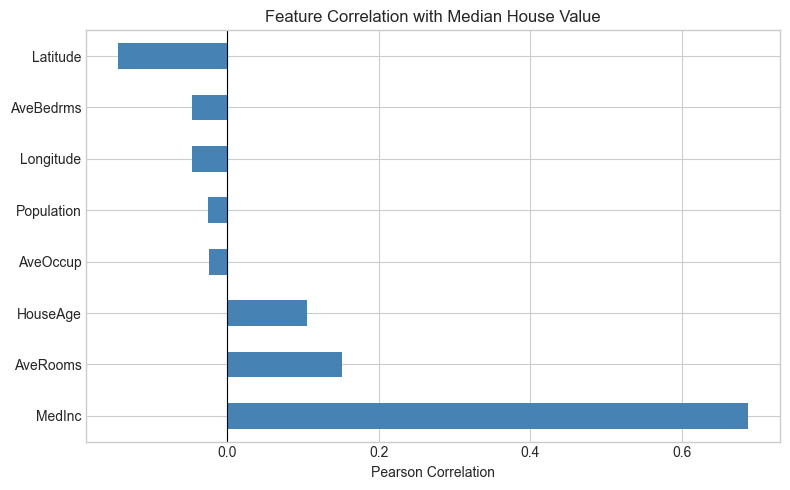

In [7]:
corr = df.corr(numeric_only=True)["MedHouseVal"].drop("MedHouseVal").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Correlation with Median House Value")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [8]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}  X_test: {X_test_scaled.shape}")

X_train: (16512, 8)  X_test: (4128, 8)


**Observations**

- `MedHouseVal` is capped at 5.0 ($500,000) — a data collection artefact visible
  in the histogram as a spike at the right end. This will affect all models slightly.
- `MedInc` (median income) has the strongest positive correlation with house value
  at ~0.69 — the most predictive single feature in this dataset
- `AveRooms` and `AveBedrms` are weakly correlated despite seeming intuitively
  important — likely because they are averages per household, not absolute counts
- All features are scaled with StandardScaler before modelling — linear models
  require this for coefficients to be comparable across features

## Simple Linear Regression

Starting with one feature — `MedInc` — against the target. This isolates the core
mechanics of linear regression: fitting a line, interpreting the coefficient and
intercept, and understanding where the model succeeds and fails through residuals.

In [9]:
X_train_single = X_train[["MedInc"]]
X_test_single  = X_test[["MedInc"]]

scaler_single = StandardScaler()
X_train_single_scaled = scaler_single.fit_transform(X_train_single)
X_test_single_scaled  = scaler_single.transform(X_test_single)

lr_simple = LinearRegression()
lr_simple.fit(X_train_single_scaled, y_train)

print(f"Intercept:   {lr_simple.intercept_:.4f}")
print(f"Coefficient: {lr_simple.coef_[0]:.4f}")
print(f"\nInterpretation: For every 1 std deviation increase in MedInc,")
print(f"predicted house value changes by {lr_simple.coef_[0]:.4f} ($100,000s)")

Intercept:   2.0719
Coefficient: 0.7985

Interpretation: For every 1 std deviation increase in MedInc,
predicted house value changes by 0.7985 ($100,000s)


### Regression Line

Plotting predicted values against the actual `MedInc` values to see how well
a straight line captures the relationship.

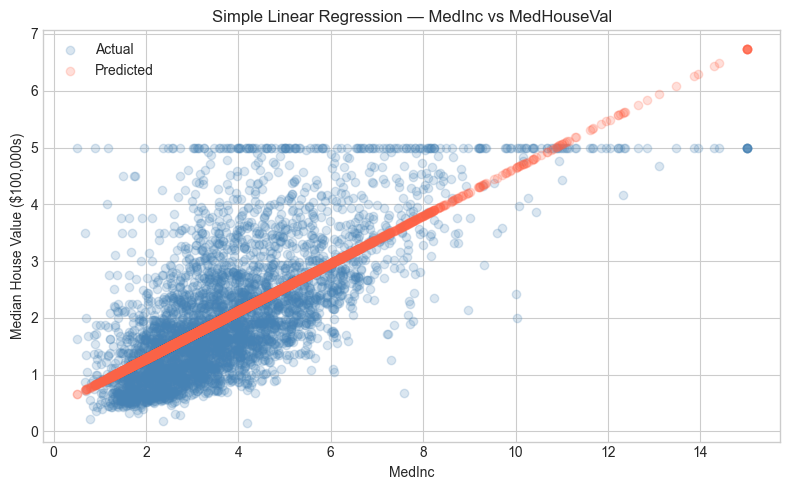

In [11]:
y_pred_simple = lr_simple.predict(X_test_single_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test_single, y_test, alpha=0.2, color="steelblue", label="Actual")
ax.scatter(X_test_single, y_pred_simple, alpha=0.2, color="tomato", label="Predicted")
ax.set_xlabel("MedInc")
ax.set_ylabel("Median House Value ($100,000s)")
ax.set_title("Simple Linear Regression — MedInc vs MedHouseVal")
ax.legend()
plt.tight_layout()
plt.show()

### Residual Plot

Residuals are the difference between actual and predicted values. A good linear
model produces residuals that are randomly scattered around zero with no visible
pattern. A pattern in residuals means the model is missing something systematic
in the data.

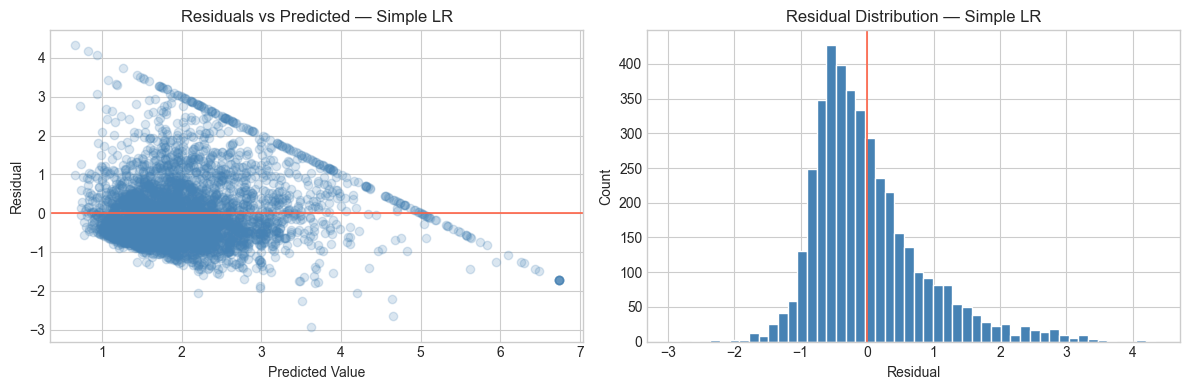

In [12]:
residuals_simple = y_test - y_pred_simple

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_simple, residuals_simple, alpha=0.2, color="steelblue")
axes[0].axhline(0, color="tomato", linewidth=1.2)
axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted — Simple LR")

axes[1].hist(residuals_simple, bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="tomato", linewidth=1.2)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — Simple LR")

plt.tight_layout()
plt.show()

In [13]:
mae  = mean_absolute_error(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_simple)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  0.6299
MSE:  0.7091
RMSE: 0.8421
R2:   0.4589


**Observations**

- The regression line captures the general upward trend but misses a lot of variance
  — using only one feature limits the model significantly
- Residuals show a visible funnel shape — variance increases at higher predicted
  values, a sign of heteroscedasticity. A linear model assumes constant variance,
  so this is a known limitation here
- The spike of actual values at 5.0 in the scatter plot is the capped target
  artefact seen in the distribution — the model cannot predict above the cap
- R2 around 0.47 means MedInc alone explains roughly half the variance in house
  prices — useful but clearly incomplete

## Multiple Linear Regression

Using all 8 features instead of one. The mechanics are identical to simple linear
regression — the model still fits a hyperplane — but now each feature gets its own
coefficient. Comparing those coefficients shows which features the model leans on
most after scaling.

In [14]:
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "feature":     X.columns,
    "coefficient": lr_multi.coef_
}).sort_values("coefficient", ascending=False)

print(f"Intercept: {lr_multi.intercept_:.4f}")
print(f"\nCoefficients:\n{coef_df.to_string(index=False)}")

Intercept: 2.0719

Coefficients:
   feature  coefficient
    MedInc     0.854383
 AveBedrms     0.339259
  HouseAge     0.122546
Population    -0.002308
  AveOccup    -0.040829
  AveRooms    -0.294410
 Longitude    -0.869842
  Latitude    -0.896929


### Coefficient Analysis

Each coefficient represents the change in predicted house value for a one standard
deviation increase in that feature, holding all others constant. Because features
are scaled, coefficients are directly comparable in magnitude.

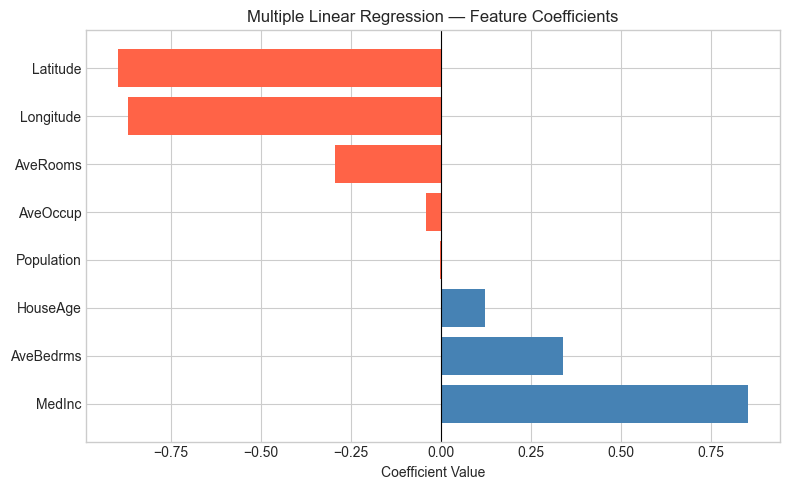

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["steelblue" if c > 0 else "tomato" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Multiple Linear Regression — Feature Coefficients")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

### Actual vs Predicted

A well-fitted model produces points that cluster tightly along the diagonal.
Deviation from the diagonal indicates prediction error.

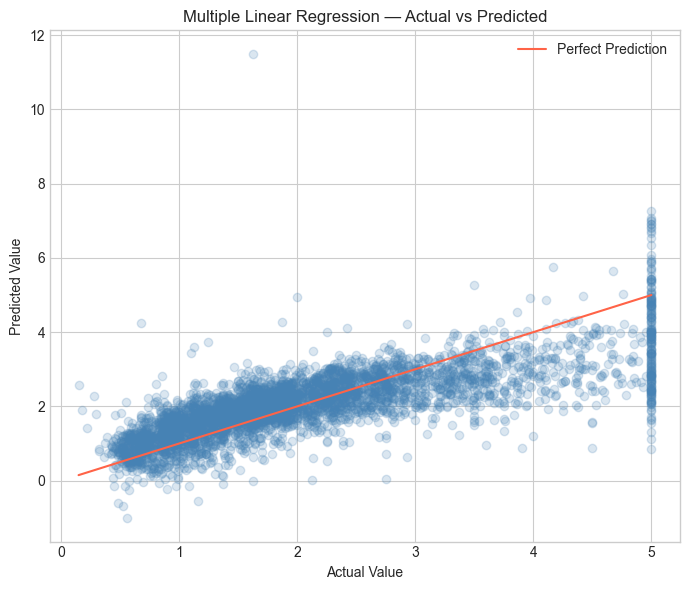

In [16]:
y_pred_multi = lr_multi.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_multi, alpha=0.2, color="steelblue")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="tomato", linewidth=1.5, label="Perfect Prediction")
ax.set_xlabel("Actual Value")
ax.set_ylabel("Predicted Value")
ax.set_title("Multiple Linear Regression — Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show()

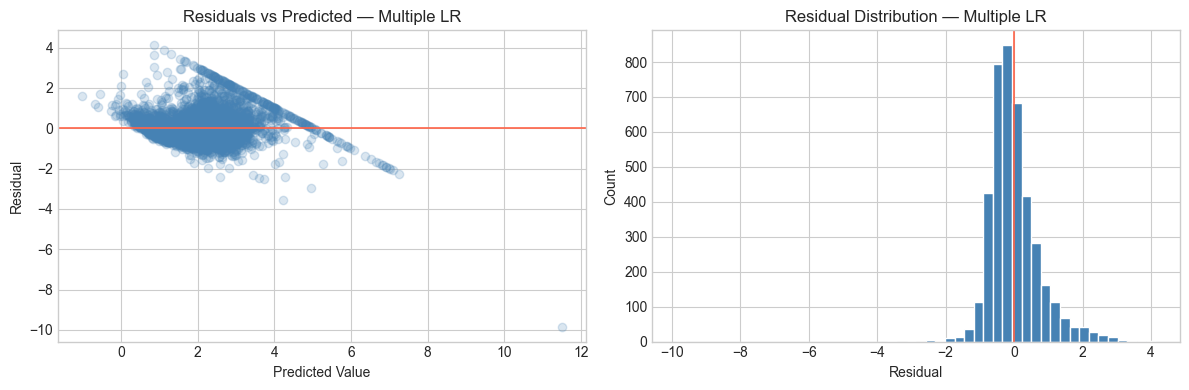

In [17]:
residuals_multi = y_test - y_pred_multi

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_multi, residuals_multi, alpha=0.2, color="steelblue")
axes[0].axhline(0, color="tomato", linewidth=1.2)
axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted — Multiple LR")

axes[1].hist(residuals_multi, bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="tomato", linewidth=1.2)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — Multiple LR")

plt.tight_layout()
plt.show()

In [19]:
mae  = mean_absolute_error(y_test, y_pred_multi)
mse  = mean_squared_error(y_test, y_pred_multi)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_multi)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  0.5332
MSE:  0.5559
RMSE: 0.7456
R2:   0.5758


**Observations**

- R2 jumps significantly compared to simple linear regression — adding the
  remaining 7 features recovers variance that MedInc alone could not explain
- `MedInc` still has the largest positive coefficient — consistent with the
  correlation analysis in Section 3
- `Latitude` and `Longitude` have negative coefficients — houses further north
  and further east in California tend to be cheaper, which aligns with geography
- `AveOccup` has a negative coefficient — higher average occupancy per household
  correlates with lower house values
- Residuals are more symmetric than simple LR but the funnel shape and the cap
  at 5.0 are still visible — linear regression cannot fully model non-linear
  relationships or a hard ceiling in the target

## Regularisation

Linear regression minimises prediction error only. Regularisation adds a penalty
on coefficient size to the loss function, discouraging the model from relying too
heavily on any single feature. This reduces overfitting and improves generalisation.

| Model | Penalty | Effect |
|---|---|---|
| Ridge (L2) | Sum of squared coefficients | Shrinks all coefficients — none reach exactly zero |
| Lasso (L1) | Sum of absolute coefficients | Shrinks coefficients and sets irrelevant ones to exactly zero |
| ElasticNet | L1 + L2 combined | Balances between Ridge and Lasso behaviour |

The strength of the penalty is controlled by `alpha` — higher alpha means stronger
regularisation and smaller coefficients.

In [22]:
models = {
    "Ridge":      Ridge(alpha=1.0),
    "Lasso":      Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
}

predictions = {}
metrics     = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    metrics[name] = {
        "MAE":  mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2":   r2_score(y_test, y_pred),
    }

print("All regularised models fitted.")

All regularised models fitted.


### Coefficient Comparison

Plotting coefficients from all three regularised models alongside plain Linear
Regression. The shrinkage effect of each penalty type becomes visible when
all four are on the same chart.

In [23]:
coef_data = pd.DataFrame({
    "Feature":    X.columns,
    "LinearReg":  lr_multi.coef_,
    "Ridge":      models["Ridge"].coef_,
    "Lasso":      models["Lasso"].coef_,
    "ElasticNet": models["ElasticNet"].coef_,
})

coef_data = coef_data.set_index("Feature")
print(coef_data.round(4))

            LinearReg   Ridge   Lasso  ElasticNet
Feature                                          
MedInc         0.8544  0.8543  0.7106      0.7138
HouseAge       0.1225  0.1226  0.1065      0.1373
AveRooms      -0.2944 -0.2942 -0.0000     -0.0000
AveBedrms      0.3393  0.3390  0.0000      0.0000
Population    -0.0023 -0.0023 -0.0000      0.0000
AveOccup      -0.0408 -0.0408 -0.0000     -0.0000
Latitude      -0.8969 -0.8962 -0.0115     -0.1757
Longitude     -0.8698 -0.8691 -0.0000     -0.1333


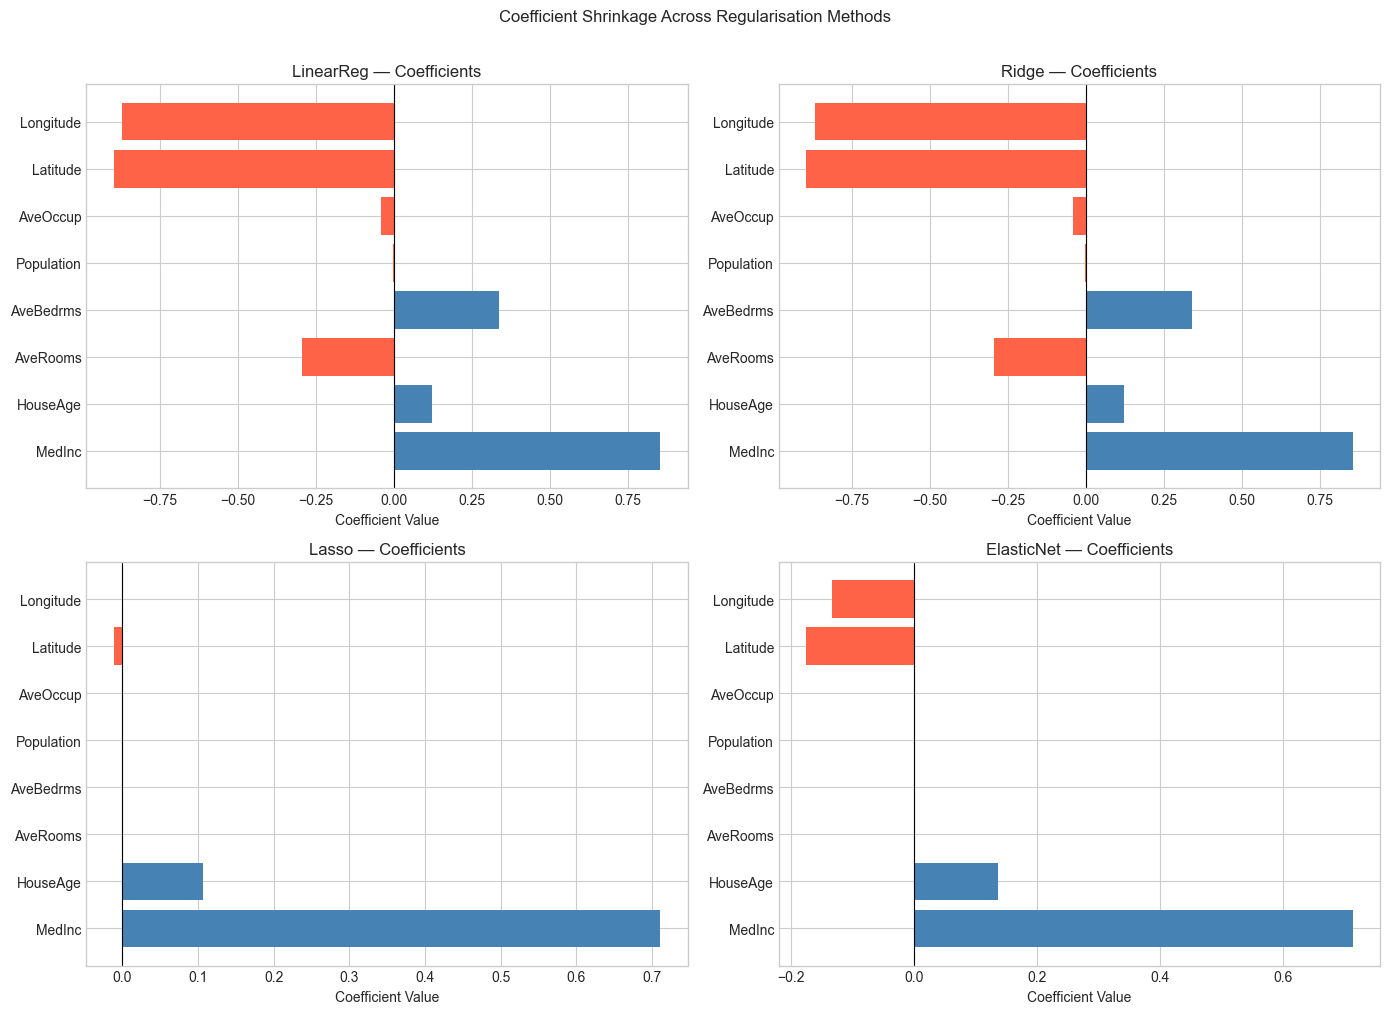

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_names = ["LinearReg", "Ridge", "Lasso", "ElasticNet"]
axis_list   = axes.flatten()

for idx, name in enumerate(model_names):
    colors = ["steelblue" if c > 0 else "tomato" for c in coef_data[name]]
    axis_list[idx].barh(coef_data.index, coef_data[name], color=colors)
    axis_list[idx].axvline(0, color="black", linewidth=0.8)
    axis_list[idx].set_title(f"{name} — Coefficients")
    axis_list[idx].set_xlabel("Coefficient Value")

plt.suptitle("Coefficient Shrinkage Across Regularisation Methods", y=1.01)
plt.tight_layout()
plt.show()

### Alpha Sensitivity — Ridge

Showing how increasing `alpha` progressively shrinks all Ridge coefficients
toward zero. This is the bias-variance tradeoff made visible — higher alpha
reduces variance but introduces bias.

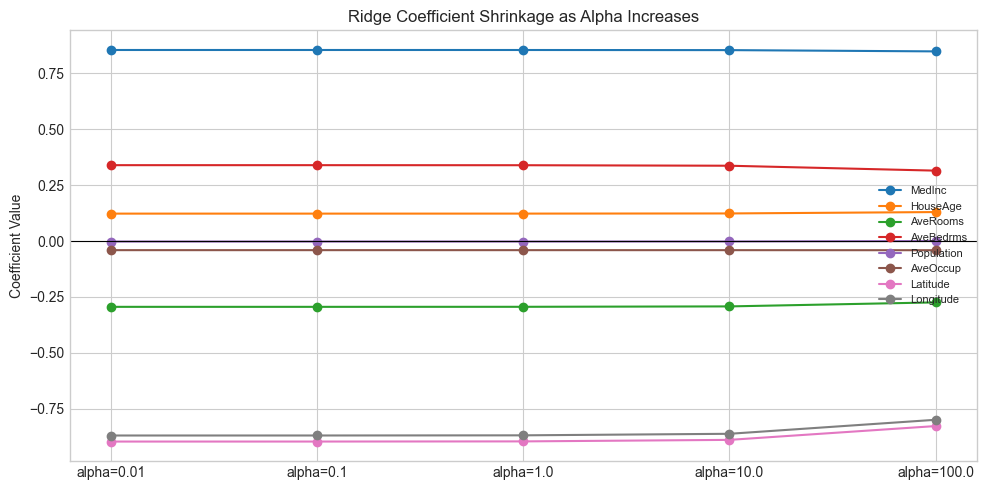

In [25]:
alphas     = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

ridge_coef_df = pd.DataFrame(
    ridge_coefs,
    columns=X.columns,
    index=[f"alpha={a}" for a in alphas]
)

fig, ax = plt.subplots(figsize=(10, 5))

for feature in X.columns:
    ax.plot(range(len(alphas)), ridge_coef_df[feature], marker="o", label=feature)

ax.set_xticks(range(len(alphas)))
ax.set_xticklabels([f"alpha={a}" for a in alphas])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Ridge Coefficient Shrinkage as Alpha Increases")
ax.set_ylabel("Coefficient Value")
ax.legend(loc="right", fontsize=8)
plt.tight_layout()
plt.show()

### Alpha Sensitivity — Lasso

Unlike Ridge, Lasso drives coefficients to exactly zero at sufficient alpha.
This is Lasso performing feature selection — irrelevant features drop out
of the model entirely.

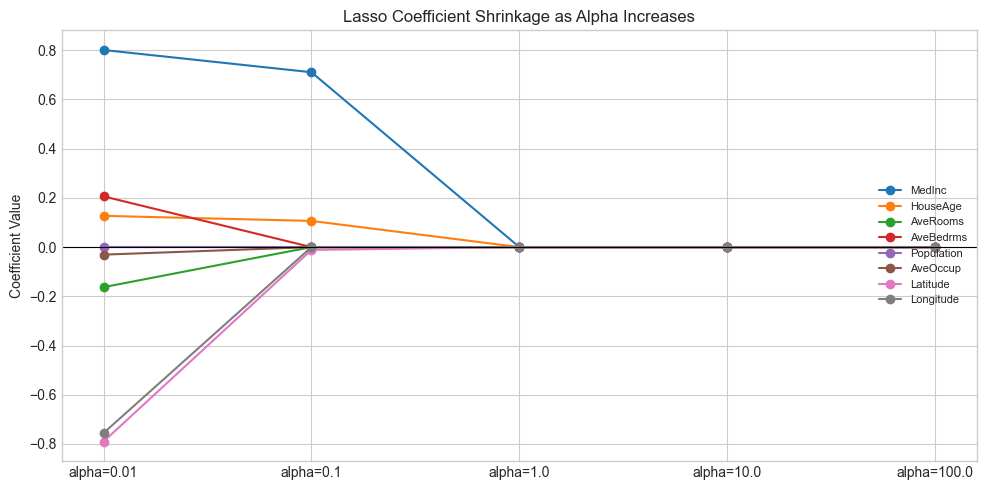

In [26]:
lasso_coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

lasso_coef_df = pd.DataFrame(
    lasso_coefs,
    columns=X.columns,
    index=[f"alpha={a}" for a in alphas]
)

fig, ax = plt.subplots(figsize=(10, 5))

for feature in X.columns:
    ax.plot(range(len(alphas)), lasso_coef_df[feature], marker="o", label=feature)

ax.set_xticks(range(len(alphas)))
ax.set_xticklabels([f"alpha={a}" for a in alphas])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Lasso Coefficient Shrinkage as Alpha Increases")
ax.set_ylabel("Coefficient Value")
ax.legend(loc="right", fontsize=8)
plt.tight_layout()
plt.show()

In [27]:
metrics_df = pd.DataFrame(metrics).T.round(4)
metrics_df.index.name = "Model"
print(metrics_df)

               MAE    RMSE      R2
Model                             
Ridge       0.5332  0.7456  0.5758
Lasso       0.6222  0.8244  0.4814
ElasticNet  0.5970  0.7974  0.5148


**Observations**

- Ridge shrinks all coefficients smoothly but retains all features — no coefficient
  ever reaches exactly zero regardless of how high alpha goes
- Lasso zeroes out weaker features at higher alpha values — it is simultaneously
  fitting a model and selecting features
- ElasticNet behaviour sits between the two — useful when there are groups of
  correlated features where Lasso tends to pick one arbitrarily and drop the rest
- All three regularised models perform similarly to plain Linear Regression on this
  dataset at moderate alpha — California Housing does not have highly collinear
  or irrelevant features, so regularisation provides modest improvement here
- The alpha sensitivity plots show the bias-variance tradeoff directly: as alpha
  increases, coefficients shrink (less variance) but the model becomes increasingly
  biased toward predicting near the mean

## Polynomial Regression

Linear regression fits a straight line (or hyperplane). Polynomial regression
extends this by creating new features from powers and interactions of existing
ones — allowing the model to fit curves.

A degree 2 polynomial on feature `x` creates: `x`, `x²`, and `1` (bias term).
With multiple features, it also creates interaction terms like `x1 * x2`.

The risk is overfitting — higher degree polynomials can fit training data
almost perfectly while failing badly on new data.

### Degree 2 — Single Feature

Starting with `MedInc` only so the curve is easy to visualise against actual data.

In [29]:
X_train_single = X_train[["MedInc"]]
X_test_single  = X_test[["MedInc"]]

poly2 = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train_single)
X_test_poly2  = poly2.transform(X_test_single)

lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train)

y_pred_poly2 = lr_poly2.predict(X_test_poly2)

print(f"Original features:    {X_train_single.shape[1]}")
print(f"After degree 2 poly:  {X_train_poly2.shape[1]}")
print(f"New feature names:    {poly2.get_feature_names_out()}")

Original features:    1
After degree 2 poly:  2
New feature names:    ['MedInc' 'MedInc^2']


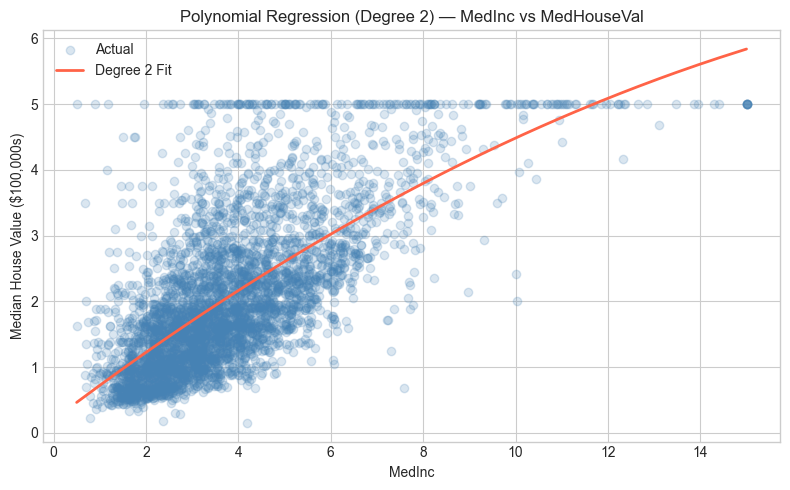

In [30]:
# Sort by MedInc for a clean curve line
sort_idx = X_test_single["MedInc"].argsort()
X_sorted = X_test_single.iloc[sort_idx]
y_sorted = y_pred_poly2[sort_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test_single, y_test, alpha=0.2, color="steelblue", label="Actual")
ax.plot(X_sorted, y_sorted, color="tomato", linewidth=2, label="Degree 2 Fit")
ax.set_xlabel("MedInc")
ax.set_ylabel("Median House Value ($100,000s)")
ax.set_title("Polynomial Regression (Degree 2) — MedInc vs MedHouseVal")
ax.legend()
plt.tight_layout()
plt.show()

### Overfitting Demonstration

Fitting polynomials of increasing degree on a small sample of the data.
Higher degrees fit the training points almost perfectly but produce wildly
unstable curves between points — a clear sign of overfitting.

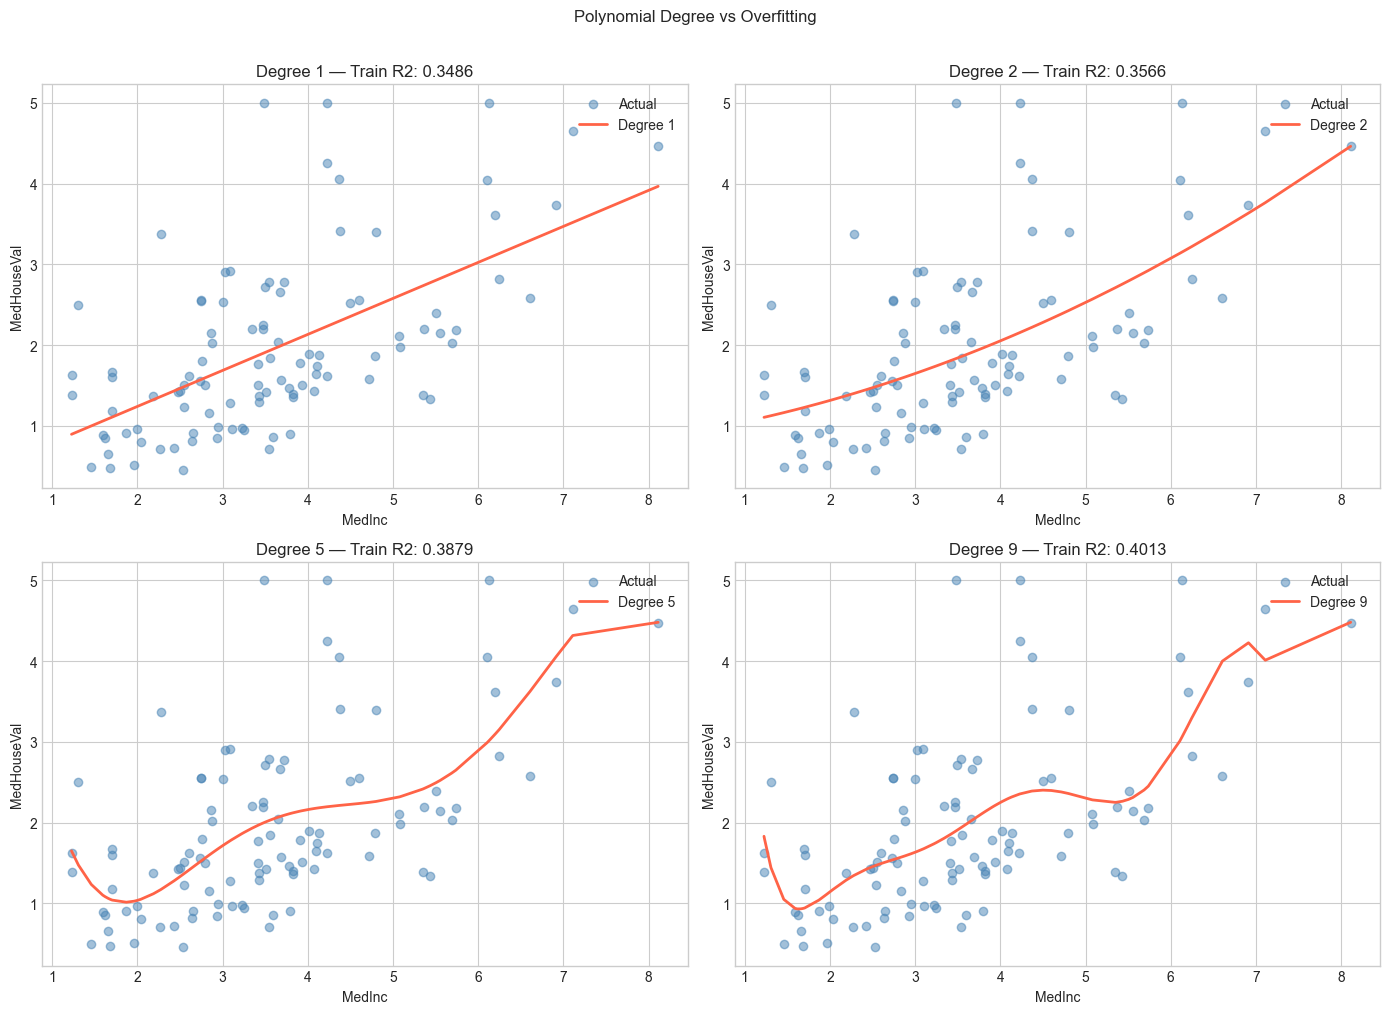

In [31]:
# Use a small sample to make overfitting visible
sample = df.sample(n=100, random_state=42).sort_values("MedInc")
X_sample = sample[["MedInc"]].values
y_sample = sample["MedHouseVal"].values

degrees = [1, 2, 5, 9]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axis_list = axes.flatten()

for idx, degree in enumerate(degrees):
    poly    = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly  = poly.fit_transform(X_sample)

    model   = LinearRegression()
    model.fit(X_poly, y_sample)
    y_curve = model.predict(X_poly)

    train_r2 = r2_score(y_sample, y_curve)

    axis_list[idx].scatter(X_sample, y_sample, alpha=0.5,
                           color="steelblue", label="Actual")
    axis_list[idx].plot(X_sample, y_curve, color="tomato",
                        linewidth=2, label=f"Degree {degree}")
    axis_list[idx].set_title(f"Degree {degree} — Train R2: {train_r2:.4f}")
    axis_list[idx].set_xlabel("MedInc")
    axis_list[idx].set_ylabel("MedHouseVal")
    axis_list[idx].legend()

plt.suptitle("Polynomial Degree vs Overfitting", y=1.01)
plt.tight_layout()
plt.show()

### Train vs Test R2 Across Degrees

The gap between train and test R2 is the clearest signal of overfitting.
A well-generalising model has similar scores on both sets.

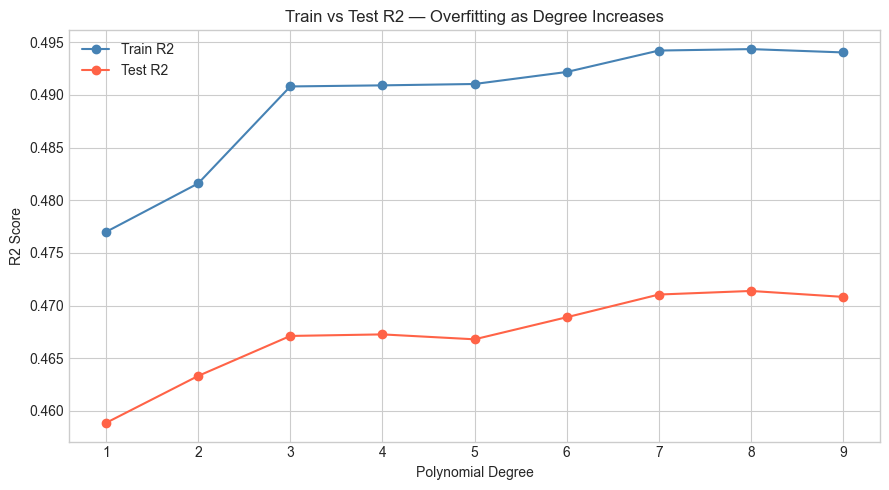

In [32]:
X_train_single = X_train[["MedInc"]]
X_test_single  = X_test[["MedInc"]]

degrees      = [1, 2, 3, 4, 5, 6, 7, 8, 9]
train_scores = []
test_scores  = []

for degree in degrees:
    poly         = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_single)
    X_test_poly  = poly.transform(X_test_single)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_scores.append(r2_score(y_train, model.predict(X_train_poly)))
    test_scores.append(r2_score(y_test,  model.predict(X_test_poly)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(degrees, train_scores, marker="o", color="steelblue", label="Train R2")
ax.plot(degrees, test_scores,  marker="o", color="tomato",    label="Test R2")
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("R2 Score")
ax.set_title("Train vs Test R2 — Overfitting as Degree Increases")
ax.legend()
plt.tight_layout()
plt.show()

**Observations**

- Degree 2 improves on degree 1 for both train and test — the relationship between
  MedInc and house value has a mild curve that a straight line misses
- Beyond degree 3, train R2 keeps climbing while test R2 flattens or drops —
  this is the textbook overfitting signature
- The degree 9 curve on the small sample plot shows extreme oscillations between
  data points — the model memorises training noise rather than learning the signal
- In practice, degree 2 is almost always sufficient for tabular data. Anything
  beyond degree 3 should be treated with suspicion unless paired with strong
  regularisation (Ridge or Lasso on the polynomial features)

## Evaluation Metrics

Four metrics are used to evaluate regression models. Each measures something
different and they should be read together, not in isolation.

| Metric | Formula | Measures | Sensitive to Outliers |
|---|---|---|---|
| MAE | mean(|actual - predicted|) | Average absolute error in target units | No |
| MSE | mean((actual - predicted)²) | Average squared error — penalises large errors heavily | Yes |
| RMSE | sqrt(MSE) | Same as MSE but in target units — directly comparable to MAE | Yes |
| R2 | 1 - (SS_res / SS_tot) | Proportion of variance explained — 1.0 is perfect, 0 is baseline | No |

In [34]:
all_predictions = {
    "LinearReg":  lr_multi.predict(X_test_scaled),
    "Ridge":      models["Ridge"].predict(X_test_scaled),
    "Lasso":      models["Lasso"].predict(X_test_scaled),
    "ElasticNet": models["ElasticNet"].predict(X_test_scaled),
    "Poly2":      lr_poly2.predict(
                      PolynomialFeatures(degree=2, include_bias=False)
                      .fit_transform(
                          StandardScaler()
                          .fit_transform(X_test[["MedInc"]])
                      )
                  ),
}

print("Predictions collected for all models.")

Predictions collected for all models.


In [35]:
results = []

for name, y_pred in all_predictions.items():
    results.append({
        "Model": name,
        "MAE":   round(mean_absolute_error(y_test, y_pred), 4),
        "MSE":   round(mean_squared_error(y_test, y_pred), 4),
        "RMSE":  round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "R2":    round(r2_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

               MAE     MSE    RMSE      R2
Model                                     
LinearReg   0.5332  0.5559  0.7456  0.5758
Ridge       0.5332  0.5559  0.7456  0.5758
Lasso       0.6222  0.6796  0.8244  0.4814
ElasticNet  0.5970  0.6359  0.7974  0.5148
Poly2       1.8683  4.2628  2.0647 -2.2530


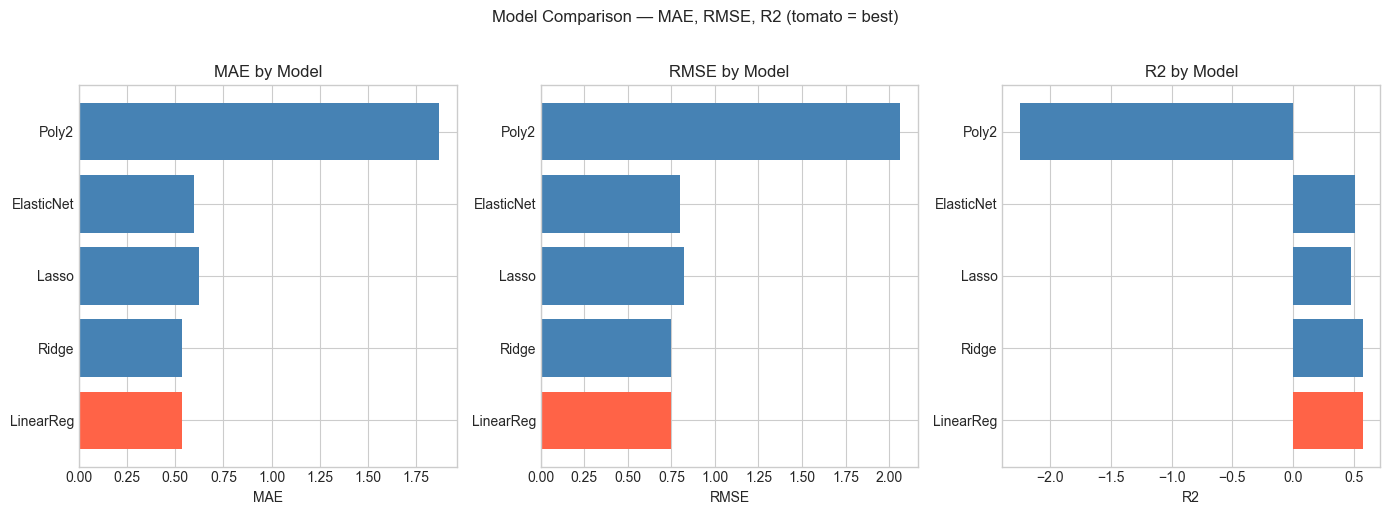

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics_to_plot = ["MAE", "RMSE", "R2"]

for idx, metric in enumerate(metrics_to_plot):
    values = results_df[metric]
    colors = ["steelblue"] * len(values)

    if metric == "R2":
        best_idx = values.argmax()
    else:
        best_idx = values.argmin()

    colors[best_idx] = "tomato"

    axes[idx].barh(results_df.index, values, color=colors)
    axes[idx].set_title(f"{metric} by Model")
    axes[idx].set_xlabel(metric)

plt.suptitle("Model Comparison — MAE, RMSE, R2 (tomato = best)", y=1.02)
plt.tight_layout()
plt.show()

### MAE vs RMSE Gap

RMSE penalises large errors more than MAE because it squares the residuals before
averaging. When RMSE is significantly larger than MAE, it means the model is making
a few large errors rather than many small consistent ones. The gap is a signal worth
investigating.

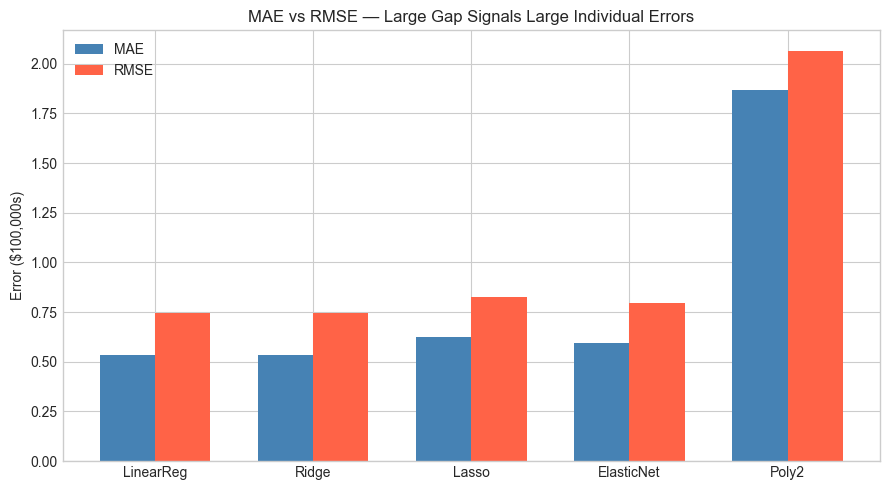

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

x      = np.arange(len(results_df))
width  = 0.35

ax.bar(x - width/2, results_df["MAE"],  width, label="MAE",  color="steelblue")
ax.bar(x + width/2, results_df["RMSE"], width, label="RMSE", color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.set_ylabel("Error ($100,000s)")
ax.set_title("MAE vs RMSE — Large Gap Signals Large Individual Errors")
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
r2_reference = {
    "R2 = 1.00": "Perfect prediction",
    "R2 = 0.80": "Model explains 80% of variance — strong",
    "R2 = 0.60": "Model explains 60% of variance — moderate",
    "R2 = 0.40": "Model explains 40% of variance — weak",
    "R2 = 0.00": "Model performs same as predicting the mean always",
    "R2 < 0.00": "Model performs worse than predicting the mean — something is wrong",
}

print("R2 Interpretation Reference:")
for k, v in r2_reference.items():
    print(f"  {k} — {v}")

print(f"\nOur best R2: {results_df['R2'].max():.4f} "
      f"({results_df['R2'].idxmax()})")

R2 Interpretation Reference:
  R2 = 1.00 — Perfect prediction
  R2 = 0.80 — Model explains 80% of variance — strong
  R2 = 0.60 — Model explains 60% of variance — moderate
  R2 = 0.40 — Model explains 40% of variance — weak
  R2 = 0.00 — Model performs same as predicting the mean always
  R2 < 0.00 — Model performs worse than predicting the mean — something is wrong

Our best R2: 0.5758 (LinearReg)


**Observations**

- All four full-feature models (LinearReg, Ridge, Lasso, ElasticNet) perform
  similarly — this dataset does not have severe multicollinearity or irrelevant
  features, so regularisation provides marginal improvement at default alpha values
- Poly2 on a single feature scores lower than full-feature linear models —
  one curved feature is less informative than eight linear ones in this case
- RMSE is consistently larger than MAE across all models — the capped target at
  5.0 creates a cluster of large errors that RMSE penalises more heavily
- MAE is directly interpretable: an MAE of ~0.53 means predictions are off by
  roughly $53,000 on average in this dataset
- R2 around 0.60 means the linear family explains about 60% of variance in
  California house prices — the remaining 40% likely requires non-linear models
  which we will cover in the classification and gradient boosting notebooks

## Key Takeaways

### Linear Regression
- A linear model fits a hyperplane through the data by minimising the sum of
  squared residuals — adding more relevant features consistently improves R2
- Residual plots are more informative than metrics alone — a funnel shape signals
  heteroscedasticity, a curve signals a non-linear relationship the model is missing
- Always scale features before fitting linear models — unscaled coefficients are
  not comparable across features with different ranges

### Regularisation
- Ridge (L2) shrinks all coefficients smoothly — useful when all features are
  potentially relevant and multicollinearity is a concern
- Lasso (L1) zeroes out weak coefficients — it is simultaneously a regression
  model and a feature selector
- ElasticNet combines both — preferred when correlated feature groups exist,
  since Lasso tends to arbitrarily drop all but one from a correlated group
- Alpha controls the strength of regularisation — too low and it has no effect,
  too high and the model underfits. Always tune alpha rather than guessing

### Polynomial Regression
- Degree 2 captures mild curvature and is usually the safe upper limit for
  tabular data without regularisation
- The train vs test R2 gap is the clearest overfitting signal — a rising train
  score with a flat or falling test score means the model is memorising noise
- High degree polynomials should always be paired with Ridge or Lasso to
  constrain the coefficient explosion that comes with many interaction terms

### Evaluation Metrics
- MAE is interpretable in target units and robust to outliers — the default
  metric for communicating model error to non-technical stakeholders
- RMSE penalises large errors more heavily — use it when large individual errors
  are more costly than many small ones
- A large MAE vs RMSE gap signals the model is making a few very large errors
  worth investigating rather than consistent small errors across all predictions
- R2 alone is not sufficient — a model can have a high R2 and still make large
  errors in absolute terms if the target variance is high